# Storage Benchmark: Database Engines

**Docker image**: `benchmark`

> **Docker required**: This notebook depends on the `benchmark` environment and
> database services. Run with:
> ```bash
> docker compose --profile benchmark up -d timescaledb clickhouse questdb influxdb
> docker compose --profile benchmark run --rm benchmark python 02_financial_data_universe/21_storage_benchmark_database.py
> ```

**Focus**: Query-capable databases for financial time-series

## Database Categories

| Category | Examples | Characteristics |
|----------|----------|-----------------|
| **Embedded** | SQLite, DuckDB, ArcticDB | In-process, no server required |
| **Time-Series Servers** | ClickHouse, QuestDB, TimescaleDB | Production-scale, Docker required |
| **General Purpose** | PostgreSQL, InfluxDB | Baseline comparisons |
| **HFT Specialized** | kdb+/PyKX | Industry standard for trading |

## Operations Benchmarked

1. **Write** - Bulk insert performance
2. **Read** - Full table scan
3. **Range Query** - 7-day time window (backtesting workflow)
4. **OHLCV Aggregation** - Resample to bars
5. **ASOF Join** - Trade-quote alignment (critical for microstructure)

## Quick Start

```bash
# Embedded only (no Docker needed)
BENCHMARK_SCALE=S uv run python storage_benchmark_databases.py

# With server databases (start Docker first)
docker compose --profile benchmark up -d timescaledb clickhouse questdb influxdb
BENCHMARK_SCALE=L uv run python storage_benchmark_databases.py
```

## Setup

In [1]:
"""Storage Benchmark — Database engine comparison for financial time-series."""

import contextlib
import gc
import json
import os
import shutil
import sqlite3
import subprocess
import time as time_module
import urllib.parse
import urllib.request
import warnings
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from utils.paths import get_output_dir
from utils.storage_benchmarks import (
    ACTIVE_SCALE,
    BENCHMARK_DIR,
    DB_CONFIG,
    N_ROWS_PER_SYMBOL,
    N_SYMBOLS,
    N_TICKS_QUOTES,
    N_TICKS_TRADES,
    TIMING_RUNS,
    WAL_FLUSH_TIMEOUT,
    BenchmarkResult,
    estimate_memory_mb,
    force_materialize_pandas,
    force_materialize_polars,
    generate_ohlcv_data,
    generate_tick_data,
    get_scale_config,
    save_benchmark_results,
    save_chart,
    time_operation,
    validate_result,
)

warnings.filterwarnings("ignore")

In [2]:
OUTPUT_DIR = get_output_dir(2, "storage_benchmark")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Production defaults — Papermill injects overrides for CI

## Check Available Databases

In [4]:
# Track benchmark status
benchmark_status = {
    # Embedded (always available if package installed)
    "SQLite": {"expected": True, "tested": False, "category": "embedded"},
    "DuckDB": {"expected": False, "tested": False, "category": "embedded"},
    "ArcticDB": {"expected": False, "tested": False, "category": "embedded"},
    # Servers (need Docker)
    "ClickHouse": {"expected": True, "tested": False, "category": "server"},
    "QuestDB": {"expected": True, "tested": False, "category": "server"},
    "TimescaleDB": {"expected": True, "tested": False, "category": "server"},
    "InfluxDB": {"expected": True, "tested": False, "category": "server"},
    "PostgreSQL": {"expected": True, "tested": False, "category": "server"},
    "kdb+/PyKX": {"expected": False, "tested": False, "category": "hft"},
}

print("=" * 70)
print(f"DATABASE BENCHMARK - Scale: {ACTIVE_SCALE}")
print("=" * 70)

# === Check Embedded Databases ===
# DuckDB ships in both the `benchmark` (ARM64) and `benchmark-full` (x86)
# images. ArcticDB is x86-only — it lives in `benchmark-full`. SQLite is
# always available via stdlib.
try:
    import duckdb  # noqa: F401
except ImportError as exc:
    raise ImportError(
        "DuckDB is not available in the current image.\n"
        "This notebook runs in the `benchmark` image:\n"
        "  docker compose --profile benchmark run --rm benchmark \\\n"
        "      python 02_financial_data_universe/21_storage_benchmark_database.py"
    ) from exc

print("\n### Embedded Databases")
benchmark_status["DuckDB"]["expected"] = True
print("[OK] DuckDB: Available")
print("[OK] SQLite: Available (built-in)")

try:
    import arcticdb as adb

    HAS_ARCTICDB = True
    benchmark_status["ArcticDB"]["expected"] = True
    print("[OK] ArcticDB: Available")
except ImportError:
    HAS_ARCTICDB = False
    print("○ ArcticDB: Not installed (x86-only — use the benchmark-full image)")

DATABASE BENCHMARK - Scale: L

### Embedded Databases
[OK] DuckDB: Available
[OK] SQLite: Available (built-in)
○ ArcticDB: Not installed (x86-only — use the benchmark-full image)


In [5]:
# === Check Server Databases ===
print("\n### Server Databases (Docker required)")

# ClickHouse
try:
    import clickhouse_connect

    ch_client = clickhouse_connect.get_client(
        host=DB_CONFIG["clickhouse"]["host"], port=DB_CONFIG["clickhouse"]["port"]
    )
    ch_client.query("SELECT 1")
    HAS_CLICKHOUSE = True
    print("[OK] ClickHouse: Available")
except Exception:
    HAS_CLICKHOUSE = False
    print("[FAIL] ClickHouse: Not available (start Docker)")

# QuestDB
try:
    urllib.request.urlopen(
        f"http://{DB_CONFIG['questdb']['host']}:{DB_CONFIG['questdb']['http_port']}/exec?query=SELECT%201",
        timeout=2,
    )
    HAS_QUESTDB = True
    print("[OK] QuestDB: Available")
except Exception:
    HAS_QUESTDB = False
    print("[FAIL] QuestDB: Not available (start Docker)")


### Server Databases (Docker required)
[OK] ClickHouse: Available
[OK] QuestDB: Available


In [6]:
# Check TimescaleDB and InfluxDB availability
try:
    import psycopg2

    ts_conn = psycopg2.connect(
        host=DB_CONFIG["timescaledb"]["host"],
        port=DB_CONFIG["timescaledb"]["port"],
        user=DB_CONFIG["timescaledb"]["user"],
        password=DB_CONFIG["timescaledb"]["password"],
        database=DB_CONFIG["timescaledb"]["database"],
        connect_timeout=2,
    )
    ts_conn.close()
    HAS_TIMESCALEDB = True
    print("[OK] TimescaleDB: Available")
except Exception:
    HAS_TIMESCALEDB = False
    print("[FAIL] TimescaleDB: Not available (start Docker)")

# InfluxDB
try:
    from influxdb_client import InfluxDBClient

    influx_test = InfluxDBClient(
        url=f"http://{DB_CONFIG['influxdb']['host']}:{DB_CONFIG['influxdb']['port']}",
        token=DB_CONFIG["influxdb"]["token"],
        org=DB_CONFIG["influxdb"]["org"],
        timeout=2000,
    )
    HAS_INFLUXDB = bool(influx_test.ready())
    influx_test.close()
    if HAS_INFLUXDB:
        print("[OK] InfluxDB: Available")
    else:
        print("[FAIL] InfluxDB: Not ready")
except Exception:
    HAS_INFLUXDB = False
    print("[FAIL] InfluxDB: Not available (start Docker)")

[OK] TimescaleDB: Available


[OK] InfluxDB: Available


In [7]:
# PostgreSQL (vanilla, separate from TimescaleDB)
try:
    import psycopg2

    pg_conn_check = psycopg2.connect(
        host=DB_CONFIG["postgres"]["host"],
        port=DB_CONFIG["postgres"]["port"],
        user=DB_CONFIG["postgres"]["user"],
        password=DB_CONFIG["postgres"]["password"],
        database=DB_CONFIG["postgres"]["database"],
        connect_timeout=2,
    )
    pg_conn_check.close()
    HAS_POSTGRES = True
    print("[OK] PostgreSQL: Available")
except Exception:
    HAS_POSTGRES = False
    print("[FAIL] PostgreSQL: Not available (start Docker)")

[OK] PostgreSQL: Available


In [8]:
# PyKX/kdb+ (IPC mode with external q process)
HAS_PYKX = False
Q_BINARY: Path | None = None

# Check multiple locations for q binary (host install or Docker mount)
Q_BINARY_LOCATIONS = [
    Path.home() / ".kx" / "bin" / "q",  # Standard location
    Path("/opt/kx/bin/q"),  # Alternative system location
]
KX_LICENSE_DIRS = [Path.home() / ".pykx", Path.home() / ".kx"]

try:
    os.environ["PYKX_UNLICENSED"] = "1"  # Import PyKX without license check
    import pykx as kx

    # Find q binary
    for q_path in Q_BINARY_LOCATIONS:
        if q_path.exists() and q_path.is_file():
            Q_BINARY = q_path
            break

    # Check for license
    has_license = any((d / "kc.lic").exists() or (d / "k4.lic").exists() for d in KX_LICENSE_DIRS)

    if Q_BINARY and has_license:
        HAS_PYKX = True
        benchmark_status["kdb+/PyKX"]["expected"] = True
        print("[OK] PyKX/kdb+: Available (IPC mode)")
    else:
        print("○ PyKX/kdb+: Optional (not configured)")
        if not Q_BINARY:
            print("    → Get free personal license: https://kx.com/kdb-personal-edition-download/")
            print(f"    → Install q binary to: {Q_BINARY_LOCATIONS[0]}")
        if not has_license:
            print(f"    → Place license file (kc.lic) in: {KX_LICENSE_DIRS[0]}")
except ImportError:
    print("○ PyKX/kdb+: Not installed (optional - uv pip install pykx)")

○ PyKX/kdb+: Not installed (optional - uv pip install pykx)


In [9]:
# Availability summary
n_embedded = 2 + int(HAS_ARCTICDB)  # sqlite + duckdb (+ arcticdb if x86)
n_servers = sum([HAS_CLICKHOUSE, HAS_QUESTDB, HAS_TIMESCALEDB, HAS_INFLUXDB, HAS_POSTGRES])
n_hft = int(HAS_PYKX)

print(f"\n[OK] {n_embedded} embedded + {n_servers} server + {n_hft} HFT database(s) available")

if n_servers == 0:
    print("\n[WARN]  No server databases. Start Docker containers:")
    print(
        "   docker compose --profile benchmark up -d timescaledb clickhouse questdb influxdb postgres"
    )


[OK] 2 embedded + 5 server + 0 HFT database(s) available


## Generate Test Data

In [10]:
scale_cfg = get_scale_config(ACTIVE_SCALE)
print(f"\nTarget: {scale_cfg['target_memory']} in-memory")
print(f"OHLCV: {N_SYMBOLS} symbols × {N_ROWS_PER_SYMBOL:,} rows/symbol")
print(f"Tick: {N_TICKS_TRADES:,} trades, {N_TICKS_QUOTES:,} quotes")

print("\n=== Generating synthetic data ===\n")

# Generate OHLCV data
ohlcv_df = generate_ohlcv_data(n_symbols=N_SYMBOLS, n_rows=N_ROWS_PER_SYMBOL)
total_rows = len(ohlcv_df)
memory_mb = estimate_memory_mb(ohlcv_df)
print(f"OHLCV data: {total_rows:,} rows ({memory_mb:.2f} MB)")

# Generate tick data for ASOF joins
trades_df, quotes_df = generate_tick_data(
    n_trades=N_TICKS_TRADES, n_quotes=N_TICKS_QUOTES, n_symbols=N_SYMBOLS
)
print(f"Tick data: {len(trades_df):,} trades, {len(quotes_df):,} quotes")

# pandas versions (some tools require pandas)
ohlcv_pandas = ohlcv_df.to_pandas()
trades_pandas = trades_df.to_pandas()
quotes_pandas = quotes_df.to_pandas()

# Results collection
results: list[BenchmarkResult] = []


Target: 100MB in-memory
OHLCV: 100 symbols × 10,000 rows/symbol
Tick: 500,000 trades, 2,500,000 quotes

=== Generating synthetic data ===



OHLCV data: 1,000,000 rows (63.90 MB)


Tick data: 500,000 trades, 2,500,000 quotes


---
# Part 1: Embedded Databases
---

## SQLite (Embedded RDBMS)

SQLite is an embedded relational database:
- ACID compliant, single-file database
- Good for transactional workloads (OLTP)
- Limited analytical query optimization
- No native ASOF join

In [11]:
print("\n" + "=" * 70)
print("SQLITE BENCHMARK")
print("=" * 70)

benchmark_status["SQLite"]["tested"] = True
sqlite_path = BENCHMARK_DIR / f"ohlcv_{ACTIVE_SCALE.lower()}.db"


# Write
def write_sqlite():
    if sqlite_path.exists():
        sqlite_path.unlink()
    with contextlib.closing(sqlite3.connect(sqlite_path)) as conn:
        ohlcv_pandas.to_sql("ohlcv", conn, if_exists="replace", index=False)
        conn.execute("CREATE INDEX IF NOT EXISTS idx_symbol_timestamp ON ohlcv(symbol, timestamp)")


gc.collect()
write_time, _ = time_operation(write_sqlite)
sqlite_size = sqlite_path.stat().st_size
results.append(BenchmarkResult("SQLite", "write", write_time, sqlite_size, total_rows))


SQLITE BENCHMARK


### SQLite Read and Aggregation

In [12]:
def read_sqlite():
    with contextlib.closing(sqlite3.connect(sqlite_path)) as conn:
        df = pd.read_sql("SELECT * FROM ohlcv", conn)
    return force_materialize_pandas(df)


gc.collect()
read_time, sqlite_result = time_operation(read_sqlite)
validate_result(sqlite_result, total_rows, "SQLite read")
results.append(BenchmarkResult("SQLite", "read", read_time, sqlite_size, total_rows))

### SQLite OHLCV Aggregation

In [13]:
def sqlite_aggregation():
    with contextlib.closing(sqlite3.connect(sqlite_path)) as conn:
        query = """
            SELECT symbol, date(timestamp) as date,
                   MIN(open) as open, MAX(high) as high, MIN(low) as low,
                   MAX(close) as close, SUM(volume) as volume
            FROM ohlcv GROUP BY symbol, date(timestamp)
        """
        return pd.read_sql(query, conn)


gc.collect()
agg_time, agg_result = time_operation(sqlite_aggregation)
results.append(BenchmarkResult("SQLite", "aggregation", agg_time, 0, len(agg_result)))

print(f"\nSQLite: {sqlite_size / 1e6:.1f} MB")
print(f"  Write: {write_time:.3f}s ({total_rows / write_time / 1e6:.2f}M rows/s)")
print(f"  Read:  {read_time:.3f}s ({total_rows / read_time / 1e6:.2f}M rows/s)")
print(f"  Aggregation: {agg_time:.3f}s ({len(agg_result):,} daily bars)")
print("  Note: No native ASOF join")


SQLite: 123.3 MB
  Write: 2.523s (0.40M rows/s)
  Read:  1.820s (0.55M rows/s)
  Aggregation: 0.580s (700 daily bars)
  Note: No native ASOF join


## DuckDB (Embedded Analytics)

DuckDB is designed for analytical workloads (OLAP):
- Columnar storage, vectorized execution
- Native ASOF join support (v1.1+)
- Zero-copy reads from Parquet
- Out-of-core processing for data larger than RAM

In [14]:
print("\n" + "=" * 70)
print("DUCKDB BENCHMARK")
print("=" * 70)

benchmark_status["DuckDB"]["tested"] = True
duckdb_path = BENCHMARK_DIR / f"ohlcv_{ACTIVE_SCALE.lower()}.duckdb"
parquet_path = BENCHMARK_DIR / f"ohlcv_{ACTIVE_SCALE.lower()}.parquet"

# Save to Parquet for DuckDB's preferred workflow
ohlcv_df.write_parquet(parquet_path)


# Write DuckDB native
def write_duckdb():
    if duckdb_path.exists():
        duckdb_path.unlink()
    conn = duckdb.connect(str(duckdb_path))
    conn.execute("CREATE TABLE ohlcv AS SELECT * FROM read_parquet(?)", [str(parquet_path)])
    conn.close()


gc.collect()
write_time, _ = time_operation(write_duckdb, n_runs=1, warmup=False)
duckdb_size = duckdb_path.stat().st_size
results.append(BenchmarkResult("DuckDB", "write", write_time, duckdb_size, total_rows))


# Read
def read_duckdb():
    conn = duckdb.connect(str(duckdb_path), read_only=True)
    df = conn.execute("SELECT * FROM ohlcv").pl()
    conn.close()
    return force_materialize_polars(df)


gc.collect()
read_time, duckdb_result = time_operation(read_duckdb)
validate_result(duckdb_result, total_rows, "DuckDB read")
results.append(BenchmarkResult("DuckDB", "read", read_time, duckdb_size, total_rows))


DUCKDB BENCHMARK


In [15]:
# Aggregation
def duckdb_aggregation():
    conn = duckdb.connect(str(duckdb_path), read_only=True)
    result = conn.execute("""
        SELECT symbol, date_trunc('day', timestamp) as date,
               FIRST(open) as open, MAX(high) as high, MIN(low) as low,
               LAST(close) as close, SUM(volume) as volume
        FROM ohlcv GROUP BY symbol, date ORDER BY symbol, date
    """).pl()
    conn.close()
    return result


gc.collect()
agg_time, agg_result = time_operation(duckdb_aggregation)
results.append(BenchmarkResult("DuckDB", "aggregation", agg_time, 0, len(agg_result)))

# ASOF Join
trades_path = BENCHMARK_DIR / f"trades_{ACTIVE_SCALE.lower()}.parquet"
quotes_path = BENCHMARK_DIR / f"quotes_{ACTIVE_SCALE.lower()}.parquet"
trades_df.sort(["symbol", "timestamp"]).write_parquet(trades_path)
quotes_df.sort(["symbol", "timestamp"]).write_parquet(quotes_path)


def duckdb_asof():
    conn = duckdb.connect()
    result = conn.execute(f"""
        SELECT t.*, q.bid, q.ask, q.bid_size, q.ask_size
        FROM read_parquet('{trades_path}') t
        ASOF LEFT JOIN read_parquet('{quotes_path}') q
          ON t.symbol = q.symbol AND t.timestamp >= q.timestamp
    """).pl()
    conn.close()
    return result


gc.collect()
asof_time, asof_result = time_operation(duckdb_asof)
results.append(BenchmarkResult("DuckDB", "asof_join", asof_time, 0, len(asof_result)))

print(f"\nDuckDB: {duckdb_size / 1e6:.1f} MB")
print(f"  Write: {write_time:.3f}s ({total_rows / write_time / 1e6:.2f}M rows/s)")
print(f"  Read:  {read_time:.3f}s ({total_rows / read_time / 1e6:.2f}M rows/s)")
print(f"  Aggregation: {agg_time:.3f}s ({len(agg_result):,} daily bars)")
print(f"  ASOF Join: {asof_time:.3f}s ({N_TICKS_TRADES / asof_time / 1e6:.2f}M trades/s)")


DuckDB: 42.2 MB
  Write: 0.151s (6.61M rows/s)
  Read:  0.063s (15.83M rows/s)
  Aggregation: 0.024s (700 daily bars)
  ASOF Join: 0.225s (2.22M trades/s)


## ArcticDB (Versioned DataFrames)

ArcticDB is designed for versioned time-series storage:
- "Git for DataFrames" - version history, time travel
- Optimized for financial time-series
- LMDB backend (local), S3/Azure (cloud)

In [16]:
if HAS_ARCTICDB:
    print("\n" + "=" * 70)
    print("ARCTICDB BENCHMARK")
    print("=" * 70)

    benchmark_status["ArcticDB"]["tested"] = True
    arctic_path = BENCHMARK_DIR / f"arctic_{ACTIVE_SCALE.lower()}"

    if arctic_path.exists():
        shutil.rmtree(arctic_path)

    ac = adb.Arctic(f"lmdb://{arctic_path}")
    lib = ac.get_library("benchmark", create_if_missing=True)

    def write_arctic():
        lib.write("ohlcv", ohlcv_pandas, prune_previous_versions=True)

    gc.collect()
    write_time, _ = time_operation(write_arctic, n_runs=min(2, TIMING_RUNS))
    arctic_size = sum(f.stat().st_size for f in arctic_path.rglob("*") if f.is_file())
    results.append(BenchmarkResult("ArcticDB", "write", write_time, arctic_size, total_rows))

    def read_arctic():
        df = lib.read("ohlcv").data
        return force_materialize_pandas(df)

    gc.collect()
    read_time, arctic_result = time_operation(read_arctic, n_runs=min(2, TIMING_RUNS))
    validate_result(arctic_result, total_rows, "ArcticDB read")
    results.append(BenchmarkResult("ArcticDB", "read", read_time, arctic_size, total_rows))

    def arctic_aggregation():
        df = lib.read("ohlcv").data
        return (
            df.groupby(["symbol", pd.Grouper(key="timestamp", freq="D")])
            .agg(
                open=("open", "first"),
                high=("high", "max"),
                low=("low", "min"),
                close=("close", "last"),
                volume=("volume", "sum"),
            )
            .reset_index()
        )

    gc.collect()
    agg_time, agg_result = time_operation(arctic_aggregation, n_runs=min(2, TIMING_RUNS))
    results.append(BenchmarkResult("ArcticDB", "aggregation", agg_time, 0, len(agg_result)))

    print(f"\nArcticDB: {arctic_size / 1e6:.1f} MB")
    print(f"  Write: {write_time:.3f}s ({total_rows / write_time / 1e6:.2f}M rows/s)")
    print(f"  Read:  {read_time:.3f}s ({total_rows / read_time / 1e6:.2f}M rows/s)")
    print(f"  Aggregation: {agg_time:.3f}s ({len(agg_result):,} daily bars)")
    print("  Note: Versioning enabled (time travel supported)")

    shutil.rmtree(arctic_path)
else:
    print("\nArcticDB benchmark skipped — install via the benchmark-full image (x86 only).")


ArcticDB benchmark skipped — install via the benchmark-full image (x86 only).


---
# Part 2: Server Databases (Docker Required)
---

## ClickHouse (OLAP Analytics)

ClickHouse excels at:
- Massive aggregations (billions of rows/second)
- Columnar compression (10-15x)
- Native ASOF JOIN

In [17]:
if HAS_CLICKHOUSE:
    print("\n" + "=" * 70)
    print("CLICKHOUSE BENCHMARK")
    print("=" * 70)

    benchmark_status["ClickHouse"]["tested"] = True

    ch_client.command("DROP TABLE IF EXISTS ohlcv_benchmark")
    ch_client.command("""
        CREATE TABLE ohlcv_benchmark (
            timestamp DateTime64(3), symbol String,
            open Float64, high Float64, low Float64, close Float64,
            volume Int64, vwap Float64, num_trades Int32
        ) ENGINE = MergeTree()
        PARTITION BY toYYYYMM(timestamp) ORDER BY (symbol, timestamp)
    """)

    # Write
    def write_clickhouse():
        ch_client.insert_df("ohlcv_benchmark", ohlcv_pandas)

    ch_write_time, _ = time_operation(write_clickhouse, n_runs=1, warmup=False)
    ch_size = (
        ch_client.query(
            "SELECT sum(bytes_on_disk) FROM system.parts WHERE table = 'ohlcv_benchmark'"
        ).result_set[0][0]
        or 0
    )
    results.append(BenchmarkResult("ClickHouse", "write", ch_write_time, ch_size, total_rows))

    # Read
    def read_clickhouse():
        return ch_client.query_df("SELECT * FROM ohlcv_benchmark")

    ch_read_time, ch_result = time_operation(read_clickhouse, n_runs=min(3, TIMING_RUNS))
    validate_result(ch_result, total_rows, "ClickHouse read")
    results.append(BenchmarkResult("ClickHouse", "read", ch_read_time, ch_size, total_rows))


CLICKHOUSE BENCHMARK


In [18]:
if HAS_CLICKHOUSE:
    # Aggregation
    def clickhouse_ohlcv():
        return ch_client.query_df("""
            SELECT symbol, toStartOfMinute(timestamp) as bar_time,
                   argMin(open, timestamp) as open, max(high) as high,
                   min(low) as low, argMax(close, timestamp) as close,
                   sum(volume) as volume
            FROM ohlcv_benchmark GROUP BY symbol, bar_time ORDER BY symbol, bar_time
        """)

    ch_agg_time, ch_agg_result = time_operation(clickhouse_ohlcv, n_runs=min(3, TIMING_RUNS))

In [19]:
if HAS_CLICKHOUSE:
    # ASOF JOIN
    ch_client.command("DROP TABLE IF EXISTS ch_trades")
    ch_client.command("DROP TABLE IF EXISTS ch_quotes")
    ch_client.command("""
        CREATE TABLE ch_trades (timestamp DateTime64(9), symbol String, price Float64, size Int64)
        ENGINE = MergeTree() ORDER BY (symbol, timestamp)
    """)
    ch_client.command("""
        CREATE TABLE ch_quotes (timestamp DateTime64(9), symbol String, bid Float64, ask Float64, bid_size Int64, ask_size Int64)
        ENGINE = MergeTree() ORDER BY (symbol, timestamp)
    """)

    trades_sorted_pd = (
        trades_df.sort(["symbol", "timestamp"])
        .select(["timestamp", "symbol", "price", "size"])
        .to_pandas()
    )
    quotes_sorted_pd = (
        quotes_df.sort(["symbol", "timestamp"])
        .select(["timestamp", "symbol", "bid", "ask", "bid_size", "ask_size"])
        .to_pandas()
    )
    ch_client.insert_df("ch_trades", trades_sorted_pd)
    ch_client.insert_df("ch_quotes", quotes_sorted_pd)

In [20]:
if HAS_CLICKHOUSE:

    def clickhouse_asof():
        return ch_client.query_df("""
            SELECT t.timestamp, t.symbol, t.price, t.size, q.bid, q.ask
            FROM ch_trades t ASOF LEFT JOIN ch_quotes q
            ON t.symbol = q.symbol AND t.timestamp >= q.timestamp
        """)

    ch_asof_time, ch_asof_result = time_operation(clickhouse_asof, n_runs=min(3, TIMING_RUNS))
    results.append(BenchmarkResult("ClickHouse", "asof_join", ch_asof_time, 0, len(ch_asof_result)))

    print(f"\nClickHouse: {ch_size / 1e6:.1f} MB")
    print(f"  Write: {ch_write_time:.3f}s | Read: {ch_read_time:.3f}s")
    print(f"  Aggregation: {ch_agg_time:.3f}s ({len(ch_agg_result):,} bars)")
    print(f"  ASOF Join: {ch_asof_time:.3f}s ({len(ch_asof_result):,} rows)")

    ch_client.command("DROP TABLE IF EXISTS ohlcv_benchmark")
    ch_client.command("DROP TABLE IF EXISTS ch_trades")
    ch_client.command("DROP TABLE IF EXISTS ch_quotes")
else:
    print("\n⊘ ClickHouse benchmark skipped")


ClickHouse: 53.1 MB
  Write: 1.107s | Read: 0.373s
  Aggregation: 0.459s (1,000,000 bars)
  ASOF Join: 0.278s (500,000 rows)


## QuestDB (High-Throughput Time-Series)

QuestDB is optimized for:
- Ultra-high ingestion (1M+ rows/second via ILP)
- Time-series specific SQL extensions (SAMPLE BY)
- Native ASOF JOIN

In [21]:
if HAS_QUESTDB:
    print("\n" + "=" * 70)
    print("QUESTDB BENCHMARK")
    print("=" * 70)

    benchmark_status["QuestDB"]["tested"] = True
    from questdb.ingress import Sender

    def questdb_query(sql):
        url = f"http://{DB_CONFIG['questdb']['host']}:{DB_CONFIG['questdb']['http_port']}/exec?query={urllib.parse.quote(sql)}"
        response = urllib.request.urlopen(url, timeout=30)
        return json.loads(response.read())

    with contextlib.suppress(Exception):
        questdb_query("DROP TABLE IF EXISTS ohlcv_benchmark")

    questdb_query("""
        CREATE TABLE IF NOT EXISTS ohlcv_benchmark (
            timestamp TIMESTAMP, symbol SYMBOL,
            open DOUBLE, high DOUBLE, low DOUBLE, close DOUBLE,
            volume LONG, vwap DOUBLE, num_trades INT
        ) timestamp(timestamp) PARTITION BY DAY WAL
    """)

    # Write via ILP
    def write_questdb():
        with Sender.from_conf(
            f"http::addr={DB_CONFIG['questdb']['host']}:{DB_CONFIG['questdb']['http_port']};"
        ) as sender:
            df_insert = ohlcv_pandas.copy()
            df_insert["timestamp"] = pd.to_datetime(df_insert["timestamp"])
            sender.dataframe(
                df_insert, table_name="ohlcv_benchmark", symbols=["symbol"], at="timestamp"
            )

    qdb_write_time, _ = time_operation(write_questdb, n_runs=1, warmup=False)
    time_module.sleep(WAL_FLUSH_TIMEOUT)
    results.append(BenchmarkResult("QuestDB", "write", qdb_write_time, 0, total_rows))


QUESTDB BENCHMARK


In [22]:
if HAS_QUESTDB:
    # Read
    def read_questdb():
        return questdb_query("SELECT * FROM ohlcv_benchmark")

    qdb_read_time, _ = time_operation(read_questdb, n_runs=min(3, TIMING_RUNS))
    results.append(BenchmarkResult("QuestDB", "read", qdb_read_time, 0, total_rows))

    # OHLCV aggregation (SAMPLE BY)
    def questdb_ohlcv():
        return questdb_query("""
            SELECT symbol, timestamp as bar_time,
                   first(open) as open, max(high) as high, min(low) as low,
                   last(close) as close, sum(volume) as volume
            FROM ohlcv_benchmark SAMPLE BY 1m ALIGN TO CALENDAR
        """)

    qdb_agg_time, qdb_agg_result = time_operation(questdb_ohlcv, n_runs=min(3, TIMING_RUNS))
    qdb_agg_rows = len(qdb_agg_result.get("dataset", [])) if qdb_agg_result else 0

    print("\nQuestDB:")
    print(f"  Write (ILP): {qdb_write_time:.3f}s | Read: {qdb_read_time:.3f}s")
    print(f"  OHLCV aggregation: {qdb_agg_time:.3f}s ({qdb_agg_rows} bars)")

    with contextlib.suppress(Exception):
        questdb_query("DROP TABLE IF EXISTS ohlcv_benchmark")
else:
    print("\n⊘ QuestDB benchmark skipped")


QuestDB:
  Write (ILP): 0.777s | Read: 2.618s
  OHLCV aggregation: 2.400s (1000000 bars)


## TimescaleDB (PostgreSQL + Time-Series)

TimescaleDB combines PostgreSQL with time-series optimizations:
- Hypertables (automatic partitioning)
- time_bucket() for aggregations
- Full SQL + relational integrity

In [23]:
if HAS_TIMESCALEDB:
    print("\n" + "=" * 70)
    print("TIMESCALEDB BENCHMARK")
    print("=" * 70)

    benchmark_status["TimescaleDB"]["tested"] = True
    from psycopg2.extras import execute_values

    conn = psycopg2.connect(
        host=DB_CONFIG["timescaledb"]["host"],
        port=DB_CONFIG["timescaledb"]["port"],
        user=DB_CONFIG["timescaledb"]["user"],
        password=DB_CONFIG["timescaledb"]["password"],
        database=DB_CONFIG["timescaledb"]["database"],
    )
    conn.autocommit = True
    cur = conn.cursor()

    cur.execute("CREATE EXTENSION IF NOT EXISTS timescaledb CASCADE;")
    cur.execute("DROP TABLE IF EXISTS ohlcv_benchmark CASCADE;")
    cur.execute("""
        CREATE TABLE ohlcv_benchmark (
            timestamp TIMESTAMPTZ NOT NULL, symbol TEXT NOT NULL,
            open DOUBLE PRECISION, high DOUBLE PRECISION, low DOUBLE PRECISION,
            close DOUBLE PRECISION, volume BIGINT, vwap DOUBLE PRECISION, num_trades INTEGER
        );
    """)
    cur.execute(
        "SELECT create_hypertable('ohlcv_benchmark', 'timestamp', chunk_time_interval => INTERVAL '1 day');"
    )


TIMESCALEDB BENCHMARK


In [24]:
if HAS_TIMESCALEDB:
    # Write
    def write_timescaledb():
        data = [
            (
                row["timestamp"],
                row["symbol"],
                row["open"],
                row["high"],
                row["low"],
                row["close"],
                int(row["volume"]),
                row["vwap"],
                int(row["num_trades"]),
            )
            for _, row in ohlcv_pandas.iterrows()
        ]
        execute_values(
            cur,
            """
            INSERT INTO ohlcv_benchmark (timestamp, symbol, open, high, low, close, volume, vwap, num_trades) VALUES %s
        """,
            data,
        )

    ts_write_time, _ = time_operation(write_timescaledb, n_runs=1, warmup=False)
    cur.execute("SELECT pg_total_relation_size('ohlcv_benchmark');")
    ts_size = cur.fetchone()[0]
    results.append(BenchmarkResult("TimescaleDB", "write", ts_write_time, ts_size, total_rows))

In [25]:
if HAS_TIMESCALEDB:
    # Read
    def read_timescaledb():
        cur.execute("SELECT * FROM ohlcv_benchmark;")
        return cur.fetchall()

    ts_read_time, ts_result = time_operation(read_timescaledb, n_runs=min(3, TIMING_RUNS))
    validate_result(ts_result, total_rows, "TimescaleDB read")
    results.append(BenchmarkResult("TimescaleDB", "read", ts_read_time, ts_size, total_rows))

In [26]:
if HAS_TIMESCALEDB:
    # Aggregation (time_bucket)
    def timescaledb_ohlcv():
        cur.execute("""
            SELECT symbol, time_bucket('1 minute', timestamp) as bar_time,
                   first(open, timestamp) as open, max(high) as high,
                   min(low) as low, last(close, timestamp) as close, sum(volume) as volume
            FROM ohlcv_benchmark GROUP BY symbol, bar_time ORDER BY symbol, bar_time;
        """)
        return cur.fetchall()

    ts_agg_time, ts_agg_result = time_operation(timescaledb_ohlcv, n_runs=min(3, TIMING_RUNS))

    print(f"\nTimescaleDB: {ts_size / 1e6:.1f} MB")
    print(f"  Write: {ts_write_time:.3f}s | Read: {ts_read_time:.3f}s")
    print(f"  OHLCV aggregation: {ts_agg_time:.3f}s ({len(ts_agg_result):,} bars)")

    cur.execute("DROP TABLE IF EXISTS ohlcv_benchmark CASCADE;")
    cur.close()
    conn.close()
else:
    print("\n⊘ TimescaleDB benchmark skipped")


TimescaleDB: 0.0 MB
  Write: 71.591s | Read: 2.603s
  OHLCV aggregation: 8.807s (1,000,000 bars)


## PostgreSQL (Vanilla RDBMS Baseline)

Vanilla PostgreSQL serves as the relational baseline: same SQL surface as
TimescaleDB but without hypertables, compression, or time-series functions.
The comparison isolates what TimescaleDB's time-series extensions buy you
on the same engine.

In [27]:
if HAS_POSTGRES:
    print("\n" + "=" * 70)
    print("POSTGRESQL BENCHMARK")
    print("=" * 70)

    benchmark_status["PostgreSQL"]["tested"] = True
    from psycopg2.extras import execute_values

    pg_conn = psycopg2.connect(
        host=DB_CONFIG["postgres"]["host"],
        port=DB_CONFIG["postgres"]["port"],
        user=DB_CONFIG["postgres"]["user"],
        password=DB_CONFIG["postgres"]["password"],
        database=DB_CONFIG["postgres"]["database"],
    )
    pg_conn.autocommit = True
    pg_cur = pg_conn.cursor()

    pg_cur.execute("DROP TABLE IF EXISTS ohlcv_benchmark CASCADE;")
    pg_cur.execute("""
        CREATE TABLE ohlcv_benchmark (
            timestamp TIMESTAMPTZ NOT NULL, symbol TEXT NOT NULL,
            open DOUBLE PRECISION, high DOUBLE PRECISION, low DOUBLE PRECISION,
            close DOUBLE PRECISION, volume BIGINT, vwap DOUBLE PRECISION, num_trades INTEGER
        );
    """)
    pg_cur.execute("CREATE INDEX idx_pg_symbol_timestamp ON ohlcv_benchmark(symbol, timestamp);")


POSTGRESQL BENCHMARK


In [28]:
if HAS_POSTGRES:
    # Write
    def write_postgres():
        data = [
            (
                row["timestamp"],
                row["symbol"],
                row["open"],
                row["high"],
                row["low"],
                row["close"],
                int(row["volume"]),
                row["vwap"],
                int(row["num_trades"]),
            )
            for _, row in ohlcv_pandas.iterrows()
        ]
        execute_values(
            pg_cur,
            """
            INSERT INTO ohlcv_benchmark (timestamp, symbol, open, high, low, close, volume, vwap, num_trades) VALUES %s
        """,
            data,
        )

    pg_write_time, _ = time_operation(write_postgres, n_runs=1, warmup=False)
    pg_cur.execute("SELECT pg_total_relation_size('ohlcv_benchmark');")
    pg_size = pg_cur.fetchone()[0]
    results.append(BenchmarkResult("PostgreSQL", "write", pg_write_time, pg_size, total_rows))

In [29]:
if HAS_POSTGRES:
    # Read
    def read_postgres():
        pg_cur.execute("SELECT * FROM ohlcv_benchmark;")
        return pg_cur.fetchall()

    pg_read_time, pg_result = time_operation(read_postgres, n_runs=min(3, TIMING_RUNS))
    validate_result(pg_result, total_rows, "PostgreSQL read")
    results.append(BenchmarkResult("PostgreSQL", "read", pg_read_time, pg_size, total_rows))

In [30]:
if HAS_POSTGRES:
    # Aggregation (date_trunc to the minute; emulates time_bucket without TimescaleDB extension)
    def postgres_ohlcv():
        pg_cur.execute("""
            SELECT symbol, date_trunc('minute', timestamp) as bar_time,
                   (array_agg(open ORDER BY timestamp))[1] as open,
                   max(high) as high, min(low) as low,
                   (array_agg(close ORDER BY timestamp DESC))[1] as close,
                   sum(volume) as volume
            FROM ohlcv_benchmark GROUP BY symbol, bar_time ORDER BY symbol, bar_time;
        """)
        return pg_cur.fetchall()

    pg_agg_time, pg_agg_result = time_operation(postgres_ohlcv, n_runs=min(3, TIMING_RUNS))

    print(f"\nPostgreSQL: {pg_size / 1e6:.1f} MB")
    print(f"  Write: {pg_write_time:.3f}s | Read: {pg_read_time:.3f}s")
    print(f"  OHLCV aggregation: {pg_agg_time:.3f}s ({len(pg_agg_result):,} bars)")

    pg_cur.execute("DROP TABLE IF EXISTS ohlcv_benchmark CASCADE;")
    pg_cur.close()
    pg_conn.close()
else:
    print("\n⊘ PostgreSQL benchmark skipped")


PostgreSQL: 132.8 MB
  Write: 64.311s | Read: 1.960s
  OHLCV aggregation: 2.969s (1,000,000 bars)


## InfluxDB (Time-Series Database)

InfluxDB is a purpose-built time-series database with a tag-based data model
and the Flux query language. We benchmark line-protocol writes via the Python
client, full-bucket Flux reads, and per-minute aggregation via
`aggregateWindow` joined back with `pivot`.

In [31]:
if HAS_INFLUXDB:
    print("\n" + "=" * 70)
    print("INFLUXDB BENCHMARK")
    print("=" * 70)

    benchmark_status["InfluxDB"]["tested"] = True
    from influxdb_client import InfluxDBClient, Point, WritePrecision
    from influxdb_client.client.write_api import SYNCHRONOUS

    influx_url = f"http://{DB_CONFIG['influxdb']['host']}:{DB_CONFIG['influxdb']['port']}"
    influx_org = DB_CONFIG["influxdb"]["org"]
    influx_token = DB_CONFIG["influxdb"]["token"]
    influx_bucket = DB_CONFIG["influxdb"]["bucket"]

    # Read timeout in ms: the L-scale (1M-row) Flux read + aggregate/pivot queries
    # take well over the client default, so allow several minutes before giving up.
    influx_client = InfluxDBClient(
        url=influx_url, token=influx_token, org=influx_org, timeout=600_000
    )

    # Recreate the bucket for a clean run
    buckets_api = influx_client.buckets_api()
    existing = buckets_api.find_bucket_by_name(influx_bucket)
    if existing is not None:
        buckets_api.delete_bucket(existing)
    orgs = influx_client.organizations_api().find_organizations()
    org = next((o for o in orgs if o.name == influx_org), None)
    if org is None:
        raise RuntimeError(f"InfluxDB org {influx_org!r} not found on the server")
    buckets_api.create_bucket(bucket_name=influx_bucket, org_id=org.id)


INFLUXDB BENCHMARK


In [32]:
if HAS_INFLUXDB and benchmark_status["InfluxDB"]["tested"]:
    # Write — build line-protocol Points, batch via the synchronous WriteApi
    influx_write_api = influx_client.write_api(write_options=SYNCHRONOUS)

    _influx_ts = pd.to_datetime(ohlcv_pandas["timestamp"])
    if _influx_ts.dt.tz is None:
        _influx_ts = _influx_ts.dt.tz_localize("UTC")
    else:
        _influx_ts = _influx_ts.dt.tz_convert("UTC")
    influx_ts_pandas = _influx_ts

    def write_influxdb():
        # Per-row Point construction is timed alongside the write to stay
        # apples-to-apples with TimescaleDB/PostgreSQL, which build their
        # rows inside the timed function. Pulling the comprehension out would
        # bias InfluxDB favorably by excluding serialization cost.
        points = [
            Point("ohlcv")
            .tag("symbol", row.symbol)
            .field("open", float(row.open))
            .field("high", float(row.high))
            .field("low", float(row.low))
            .field("close", float(row.close))
            .field("volume", int(row.volume))
            .field("vwap", float(row.vwap))
            .field("num_trades", int(row.num_trades))
            .time(ts, WritePrecision.NS)
            for ts, row in zip(influx_ts_pandas, ohlcv_pandas.itertuples(index=False), strict=False)
        ]
        # Batch writes to keep memory and request size bounded.
        batch_size = 10_000
        for i in range(0, len(points), batch_size):
            influx_write_api.write(
                bucket=influx_bucket, org=influx_org, record=points[i : i + batch_size]
            )

    influx_write_time, _ = time_operation(write_influxdb, n_runs=1, warmup=False)
    time_module.sleep(WAL_FLUSH_TIMEOUT)
    results.append(BenchmarkResult("InfluxDB", "write", influx_write_time, 0, total_rows))

In [33]:
if HAS_INFLUXDB and benchmark_status["InfluxDB"]["tested"]:
    # Read — pivot rows back so each timestamp yields one record across all fields
    influx_query_api = influx_client.query_api()

    read_flux = f"""
    from(bucket: "{influx_bucket}")
      |> range(start: 0)
      |> filter(fn: (r) => r._measurement == "ohlcv")
      |> pivot(rowKey:["_time","symbol"], columnKey:["_field"], valueColumn:"_value")
      |> keep(columns:["_time","symbol","open","high","low","close","volume","vwap","num_trades"])
    """

    def read_influxdb():
        tables = influx_query_api.query(read_flux, org=influx_org)
        rows = []
        for table in tables:
            for record in table.records:
                rows.append(record.values)
        return rows

    influx_read_time, influx_result = time_operation(read_influxdb, n_runs=min(3, TIMING_RUNS))
    validate_result(influx_result, total_rows, "InfluxDB read")
    results.append(BenchmarkResult("InfluxDB", "read", influx_read_time, 0, total_rows))

In [34]:
if HAS_INFLUXDB and benchmark_status["InfluxDB"]["tested"]:
    # OHLCV aggregation — bucket to 1-minute bars with the OHLCV-correct
    # reduction per field (first/max/min/last/sum), matching what TimescaleDB,
    # QuestDB, and PostgreSQL compute. Single-pass last() across all fields
    # would yield semantically wrong open/high/low/volume and would also be
    # artificially fast vs. the mixed-aggregation engines.
    agg_flux = f"""
    src = from(bucket: "{influx_bucket}")
      |> range(start: 0)
      |> filter(fn: (r) => r._measurement == "ohlcv")
    open_  = src |> filter(fn: (r) => r._field == "open")
                 |> aggregateWindow(every: 1m, fn: first, createEmpty: false)
    high_  = src |> filter(fn: (r) => r._field == "high")
                 |> aggregateWindow(every: 1m, fn: max,   createEmpty: false)
    low_   = src |> filter(fn: (r) => r._field == "low")
                 |> aggregateWindow(every: 1m, fn: min,   createEmpty: false)
    close_ = src |> filter(fn: (r) => r._field == "close")
                 |> aggregateWindow(every: 1m, fn: last,  createEmpty: false)
    vol_   = src |> filter(fn: (r) => r._field == "volume")
                 |> aggregateWindow(every: 1m, fn: sum,   createEmpty: false)
    union(tables: [open_, high_, low_, close_, vol_])
      |> pivot(rowKey:["_time","symbol"], columnKey:["_field"], valueColumn:"_value")
    """

    def influxdb_ohlcv():
        tables = influx_query_api.query(agg_flux, org=influx_org)
        return [r.values for table in tables for r in table.records]

    influx_agg_time, influx_agg_result = time_operation(influxdb_ohlcv, n_runs=min(3, TIMING_RUNS))

    print("\nInfluxDB:")
    print(f"  Write: {influx_write_time:.3f}s | Read: {influx_read_time:.3f}s")
    print(f"  OHLCV aggregation: {influx_agg_time:.3f}s ({len(influx_agg_result):,} bars)")

    influx_client.close()
else:
    print("\n⊘ InfluxDB benchmark skipped")


InfluxDB:
  Write: 22.738s | Read: 10.160s
  OHLCV aggregation: 183.411s (1,000,000 bars)


## kdb+/PyKX (HFT Industry Standard)

kdb+ is the industry standard for high-frequency trading:
- In-memory columnar storage
- Native ASOF joins (`aj` function)
- q language for array programming

**Setup**: Requires standalone q binary at `~/.kx/bin/q` with valid license
in `~/.kx/` or `~/.pykx/`. Personal licenses available from kx.com.

We use IPC mode (connecting to external q process) rather than PyKX's embedded q
because it provides more reliable license handling and better reflects production usage.

In [35]:
if HAS_PYKX:
    print("\n" + "=" * 70)
    print("KDB+/PYKX BENCHMARK (IPC mode)")
    print("=" * 70)

    # Start external q process
    Q_PORT = 5099
    q_proc = None

    try:
        print(f"Starting q server on port {Q_PORT}...")
        q_proc = subprocess.Popen(
            [str(Q_BINARY), "-p", str(Q_PORT)],
            stdin=subprocess.DEVNULL,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.PIPE,
        )
        time_module.sleep(1.0)  # Wait for q to start

        # Check if process started successfully
        if q_proc.poll() is not None:
            stderr = q_proc.stderr.read().decode() if q_proc.stderr else ""
            raise RuntimeError(f"q process failed to start: {stderr}")

        # Connect via IPC
        q = kx.SyncQConnection(port=Q_PORT)
        benchmark_status["kdb+/PyKX"]["tested"] = True
        print(f"Connected to q {q('.z.K').py()} ({q('.z.k').py()})")

        # Convert data to kdb+ format via IPC
        kdb_ohlcv = kx.toq(ohlcv_pandas)

        # Write (serialization)
        def write_pykx():
            return q("-8!", kdb_ohlcv)

        pykx_write_time, serialized = time_operation(write_pykx, warmup=False)
        pykx_size = len(bytes(serialized))
        results.append(
            BenchmarkResult("kdb+/PyKX", "write", pykx_write_time, pykx_size, total_rows)
        )

    except Exception as e:
        print(f"\n⊘ kdb+/PyKX setup failed: {e}")
        benchmark_status["kdb+/PyKX"]["tested"] = False

In [36]:
if HAS_PYKX and benchmark_status["kdb+/PyKX"]["tested"]:
    try:
        # Read (deserialization)
        def read_pykx():
            return q("-9!", serialized)

        pykx_read_time, _ = time_operation(read_pykx)
        results.append(BenchmarkResult("kdb+/PyKX", "read", pykx_read_time, pykx_size, total_rows))

    except Exception as e:
        print(f"\n⊘ kdb+/PyKX read failed: {e}")
        benchmark_status["kdb+/PyKX"]["tested"] = False

In [37]:
if HAS_PYKX and benchmark_status["kdb+/PyKX"]["tested"]:
    try:
        # ASOF Join (kdb+'s killer feature)
        kdb_trades = kx.toq(trades_df.to_pandas())
        kdb_quotes = kx.toq(quotes_df.to_pandas())
        q["trades"] = q("`symbol`timestamp xasc", kdb_trades)
        q["quotes"] = q("`symbol`timestamp xasc", kdb_quotes)

        def pykx_asof_join():
            return q("aj[`symbol`timestamp; trades; quotes]")

        pykx_asof_time, pykx_asof_result = time_operation(pykx_asof_join)
        results.append(
            BenchmarkResult("kdb+/PyKX", "asof_join", pykx_asof_time, 0, len(pykx_asof_result))
        )

        # Aggregation
        def pykx_ohlcv():
            return q(
                "{select o:first open, h:max high, l:min low, c:last close, v:sum volume "
                "by symbol, bar:`minute$timestamp from x}",
                kdb_ohlcv,
            )

        pykx_agg_time, pykx_agg_result = time_operation(pykx_ohlcv)

        print(f"\nkdb+/PyKX: {pykx_size / 1e6:.1f} MB")
        print(f"  Write: {pykx_write_time:.3f}s | Read: {pykx_read_time:.3f}s")
        print(f"  ASOF Join (aj): {pykx_asof_time:.3f}s ({len(pykx_asof_result)} rows)")
        print(f"  OHLCV aggregation: {pykx_agg_time:.3f}s ({len(pykx_agg_result.pd())} bars)")

        q.close()

    except Exception as e:
        print(f"\n⊘ kdb+/PyKX benchmark failed: {e}")
        benchmark_status["kdb+/PyKX"]["tested"] = False

    finally:
        # Clean up q process
        if q_proc and q_proc.poll() is None:
            q_proc.terminate()
            q_proc.wait(timeout=5)
            print("q server stopped")
else:
    print("\n⊘ kdb+/PyKX benchmark skipped")


⊘ kdb+/PyKX benchmark skipped


---
# Results Summary
---

In [38]:
print("\n" + "=" * 70)
print("DATABASE BENCHMARK RESULTS")
print("=" * 70)

if results:
    results_df = pl.DataFrame(
        [
            {
                "database": r.name,
                "operation": r.operation,
                "time_s": r.time_seconds,
                "size_mb": r.size_bytes / 1e6 if r.size_bytes else None,
                "rows_per_s": r.rows_per_second,
            }
            for r in results
        ]
    )

    # Summary by operation
    for op in ["write", "read", "aggregation", "asof_join"]:
        op_data = results_df.filter(pl.col("operation") == op).sort("time_s")
        if len(op_data) > 0:
            print(f"\n{op.upper().replace('_', ' ')}:")
            print(op_data.select(["database", "time_s"]))


DATABASE BENCHMARK RESULTS

WRITE:
shape: (7, 2)
┌─────────────┬───────────┐
│ database    ┆ time_s    │
│ ---         ┆ ---       │
│ str         ┆ f64       │
╞═════════════╪═══════════╡
│ DuckDB      ┆ 0.151361  │
│ QuestDB     ┆ 0.777411  │
│ ClickHouse  ┆ 1.107366  │
│ SQLite      ┆ 2.523193  │
│ InfluxDB    ┆ 22.737715 │
│ PostgreSQL  ┆ 64.310803 │
│ TimescaleDB ┆ 71.591424 │
└─────────────┴───────────┘

READ:
shape: (7, 2)
┌─────────────┬───────────┐
│ database    ┆ time_s    │
│ ---         ┆ ---       │
│ str         ┆ f64       │
╞═════════════╪═══════════╡
│ DuckDB      ┆ 0.063159  │
│ ClickHouse  ┆ 0.372765  │
│ SQLite      ┆ 1.820103  │
│ PostgreSQL  ┆ 1.95951   │
│ TimescaleDB ┆ 2.6025    │
│ QuestDB     ┆ 2.618178  │
│ InfluxDB    ┆ 10.159805 │
└─────────────┴───────────┘

AGGREGATION:
shape: (2, 2)
┌──────────┬──────────┐
│ database ┆ time_s   │
│ ---      ┆ ---      │
│ str      ┆ f64      │
╞══════════╪══════════╡
│ DuckDB   ┆ 0.024226 │
│ SQLite   ┆ 0.579919 │
└────

In [39]:
if results:
    # Visualization
    fig = make_subplots(
        rows=1, cols=2, subplot_titles=["Read Performance", "ASOF Join Performance"]
    )

    read_data = results_df.filter(pl.col("operation") == "read").sort("time_s")
    if len(read_data) > 0:
        fig.add_trace(
            go.Bar(
                y=read_data["database"].to_list(),
                x=read_data["time_s"].to_list(),
                orientation="h",
                marker_color="#0a1628",
                name="Read",
                text=[f"{t:.3f}s" for t in read_data["time_s"].to_list()],
                textposition="outside",
            ),
            row=1,
            col=1,
        )

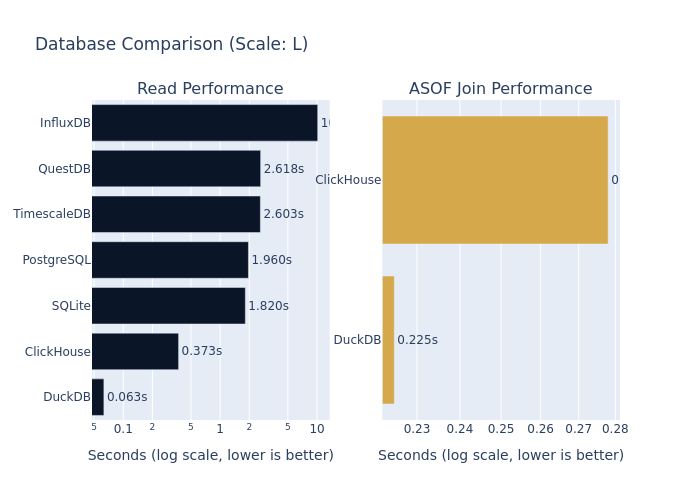

In [40]:
if results:
    asof_data = results_df.filter(pl.col("operation") == "asof_join").sort("time_s")
    if len(asof_data) > 0:
        fig.add_trace(
            go.Bar(
                y=asof_data["database"].to_list(),
                x=asof_data["time_s"].to_list(),
                orientation="h",
                marker_color="#D4A84B",
                name="ASOF Join",
                text=[f"{t:.3f}s" for t in asof_data["time_s"].to_list()],
                textposition="outside",
            ),
            row=1,
            col=2,
        )

    fig.update_layout(
        title_text=f"Database Comparison (Scale: {ACTIVE_SCALE})",
        height=500,
        showlegend=False,
    )
    # Use log scale for better visibility when timing spans orders of magnitude
    fig.update_xaxes(title_text="Seconds (log scale, lower is better)", type="log")
    fig.show()

In [41]:
if results:
    try:
        fig.write_image(
            OUTPUT_DIR / "server_database_comparison.png", width=1200, height=600, scale=2
        )
    except (RuntimeError, OSError):
        pass  # Kaleido/Chrome not available in benchmark image
    save_chart(fig, f"database_comparison_{ACTIVE_SCALE.lower()}")
    save_benchmark_results(results, "databases")

Chart saved: /app/02_financial_data_universe/.tmp/charts/database_comparison_l.html

📁 Results saved to: /app/02_financial_data_universe/output/benchmark/databases_l.csv


In [42]:
# Coverage report
print("\n### BENCHMARK COVERAGE")
tested = [k for k, v in benchmark_status.items() if v["tested"]]
expected = [k for k, v in benchmark_status.items() if v["expected"]]
print(f"Tested: {len(tested)}/{len(expected)} databases")
for db in sorted(benchmark_status.keys()):
    status = "[OK]" if benchmark_status[db]["tested"] else "[FAIL]"
    cat = benchmark_status[db]["category"]
    print(f"  {status} {db} ({cat})")

print("\n" + "=" * 70)
print("[OK] Database benchmark complete!")
print("=" * 70)


### BENCHMARK COVERAGE
Tested: 7/7 databases
  [FAIL] ArcticDB (embedded)
  [OK] ClickHouse (server)
  [OK] DuckDB (embedded)
  [OK] InfluxDB (server)
  [OK] PostgreSQL (server)
  [OK] QuestDB (server)
  [OK] SQLite (embedded)
  [OK] TimescaleDB (server)
  [FAIL] kdb+/PyKX (hft)

[OK] Database benchmark complete!


## Key Takeaways

1. **Columnar formats dominate**: DuckDB and ClickHouse offer the best read/write
   throughput thanks to columnar storage and vectorized execution.
2. **ASOF joins vary widely**: kdb+ provides sub-millisecond ASOF joins natively,
   while SQL-based databases require more complex query patterns.
3. **Choose by workload**: DuckDB for embedded analytics, ClickHouse for OLAP at scale,
   TimescaleDB when PostgreSQL compatibility matters, QuestDB for high-ingest streaming.

**Next**: See `20_storage_benchmark_file` for file-format benchmarks (Parquet, Arrow, HDF5).